<a href="https://colab.research.google.com/github/TaShapovalova/my-colab-project/blob/main/%D0%98%D1%82%D0%BE%D0%B3%D0%BE%D0%B2%D0%B0%D1%8F%F0%9F%8E%AF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

# After running the above cell and authorizing, your Google Drive will be mounted.
# IMPORTANT: Replace 'Your_Folder/Small.csv' with the actual path to your file in Google Drive.
# For example, if your file is directly in 'My Drive' and named 'my_data.csv', the path would be '/content/drive/MyDrive/my_data.csv'
file_path = '/content/drive/MyDrive/Small.csv'

try:
    # Added header=None because the initial df.head() output suggested no proper header.
    df = pd.read_csv(file_path, header=None)
    print(f"File '{file_path}' loaded successfully. First 5 rows:")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found at '{file_path}'. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File '/content/drive/MyDrive/Small.csv' loaded successfully. First 5 rows:
        0       1       2       3       4       5       6       7         8    \
0  281.1261  5.2019  4.9755  4.8077  4.6789  4.6716  4.4699  4.4669  272.5268   
1  336.6726  5.0464  4.8182  4.7258  4.5225  4.5546  4.4657  4.5582  328.6995   
2  290.2059  5.0463  4.7287  4.6207  4.5631  4.5707  4.4580  4.3681  255.7782   
3  340.9563  5.1230  4.8917  4.5914  4.6239  4.5577  4.4663  4.4310  319.4096   
4  276.8253  5.1806  4.8622  4.7099  4.5290  4.6399  4.3291  4.2316  257.5264   

      9    ...     279     280     281     282     283     284     285  \
0  4.6808  ...  0.9458  0.0000 -0.6543  0.0427  0.4482  0.7899  1.0149   
1  4.1517  ...  1.0008  0.0095  1.3937  1.3188  1.3582  1.2059  1.3286   
2  3.7374  ...  1.5204 -0.0156  1.3963  1.3386  1.4358  1.4311  1.3677   
3  4.6115  ..

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

# Загружаем три разных класса моделей
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier # Можно заменить на LGBM или XGBoost

# 1. Датасет уже загружен в DataFrame 'df' из Google Drive в предыдущей ячейке.
#    print("⏳ Загрузка датасета в память...")
#    df = pd.read_csv('Small.csv') # Эта строка была причиной ошибки FileNotFoundError
print(f"✅ Датасет уже загружен! Размерность: {df.shape}")

# 2. Выделяем признаки и таргет
# ВНИМАНИЕ: Замени 'target_column_name' на реальное имя целевого столбца, когда увидишь df.head()!
# Судя по df.head(), столбец 288 является целевым
#X = df.drop(columns=[288])
#y = df[288]
# Извлекаем целевой признак (последний столбец, индекс 288)
y = df.iloc[:, -1]

# Извлекаем все признаки, кроме последнего (столбцы от 0 до 287)
X = df.iloc[:, :-1]

print(f"Размерность признаков X: {X.shape}")  # Должно быть (100000, 288)
print(f"Размерность таргета y: {y.shape}")    # Должно быть (100000,)


# 3. Делим на обучающую и валидационную выборки (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Масштабируем признаки (критически важно для линейных моделей!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("🚀 Все готово к обучению моделей!")

✅ Датасет уже загружен! Размерность: (100000, 289)
Размерность признаков X: (100000, 288)
Размерность таргета y: (100000,)
🚀 Все готово к обучению моделей!


In [ ]:
# Принудительно переводим таргет в формат целых чисел (0 или 1) для классификации
y_train_int = y_train.astype(int)
y_val_int = y_val.astype(int)

# 1. Обучаем Логистическую регрессию
print("⏳ Обучаю Логистическую регрессию...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_int)
lr_pred = lr_model.predict(X_val_scaled)
f1_lr = f1_score(y_val_int, lr_pred, average='macro')
print(f"✅ Логистическая регрессия F1: {f1_lr:.4f}")

# 2. Обучаем Случайный лес (ограничим глубину, чтобы POCO не расплавился)
print("\n⏳ Обучаю Случайный лес (Random Forest)...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train_int)
rf_pred = rf_model.predict(X_val_scaled)
f1_rf = f1_score(y_val_int, rf_pred, average='macro')
print(f"✅ Случайный лес F1: {f1_rf:.4f}")

# 3. Обучаем Градиентный бустинг
print("\n⏳ Обучаю Градиентный бустинг...")
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_model.fit(X_train_scaled, y_train_int)
gb_pred = gb_model.predict(X_val_scaled)
f1_gb = f1_score(y_val_int, gb_pred, average='macro')
print(f"✅ Градиентный бустинг F1: {f1_gb:.4f}")

# Итоговый средний результат для аттестации
mean_f1 = (f1_lr + f1_rf + f1_gb) / 3
print(f"\n🏆 СРЕДНЯЯ F1-МЕРА ТРЕХ МОДЕЛЕЙ: {mean_f1:.4f}")

⏳ Обучаю Логистическую регрессию...
✅ Логистическая регрессия F1: 0.4774

⏳ Обучаю Случайный лес (Random Forest)...
✅ Случайный лес F1: 0.8285

⏳ Обучаю Градиентный бустинг...
✅ Градиентный бустинг F1: 0.9276

🏆 СРЕДНЯЯ F1-МЕРА ТРЕХ МОДЕЛЕЙ: 0.7445


In [ ]:
# 1. Сначала установим lightgbm (обычно он уже есть в Colab, но подстрахуемся)
!pip install lightgbm -q

import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score

# Пересобираем 3 классных классификатора:

# Модель 1: LightGBM (Обучится за 5-10 секунд!)
print("⏳ Обучаю ураганный LightGBM...")
lgb_model = lgb.LGBMClassifier(n_estimators=150, learning_rate=0.1, random_state=42, verbose=-1)
lgb_model.fit(X_train_scaled, y_train_int)
lgb_pred = lgb_model.predict(X_val_scaled)
f1_lgb = f1_score(y_val_int, lgb_pred, average='macro')
print(f"✅ LightGBM F1: {f1_lgb:.4f}")

# Модель 2: Прокачанный Случайный лес (увеличили глубину до 22)
print("\n⏳ Обучаю мощный Случайный лес...")
rf_model_v2 = RandomForestClassifier(n_estimators=150, max_depth=22, random_state=42, n_jobs=-1)
rf_model_v2.fit(X_train_scaled, y_train_int)
rf_pred_v2 = rf_model_v2.predict(X_val_scaled)
f1_rf_v2 = f1_score(y_val_int, rf_pred_v2, average='macro')
print(f"✅ Случайный лес V2 F1: {f1_rf_v2:.4f}")

# Модель 3: Градиентный бустинг (наш старый знакомый на 92%)
print("\n⏳ Переиспользую прошлый Градиентный бустинг...")
# Нам не нужно обучать его заново! Возьмем готовую модель gb_model из прошлой ячейки
f1_gb_old = f1_gb
print(f"✅ Градиентный бустинг F1: {f1_gb_old:.4f}")

# Считаем новую среднюю метрику
mean_f1_new = (f1_lgb + f1_rf_v2 + f1_gb_old) / 3
print(f"\n🏆 НОВАЯ СРЕДНЯЯ F1-МЕРА ТРЕХ МОДЕЛЕЙ: {mean_f1_new:.4f}")

⏳ Обучаю ураганный LightGBM...
✅ LightGBM F1: 0.9576

⏳ Обучаю мощный Случайный лес...
✅ Случайный лес V2 F1: 0.8918

⏳ Переиспользую прошлый Градиентный бустинг...
✅ Градиентный бустинг F1: 0.9276

🏆 НОВАЯ СРЕДНЯЯ F1-МЕРА ТРЕХ МОДЕЛЕЙ: 0.9257


In [ ]:
# 1. Устанавливаем CatBoost
!pip install catboost -q

from catboost import CatBoostClassifier
import lightgbm as lgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score

print("🏎️ ЗАПУСКАЕМ ТЯЖЕЛУЮ АРТИЛЛЕРИЮ ДЛЯ МАКСИМАЛЬНОГО БАЛЛА 🏎️\n")

# Модель 1: Наш ураганный LightGBM (переиспользуем результат 95.76%)
f1_lgb_final = 0.9576
print(f"✅ LightGBM F1: {f1_lgb_final:.4f}")

# Модель 2: Наш классический Градиентный бустинг (переиспользуем результат 92.76%)
f1_gb_final = 0.9276
print(f"✅ Градиентный бустинг F1: {f1_gb_final:.4f}")

# Модель 3: Умный CatBoost (Вместо Случайного леса)
print("\n⏳ Обучаю мощный CatBoost...")
cb_model = CatBoostClassifier(iterations=300, learning_rate=0.1, depth=7, random_state=42, verbose=0)
cb_model.fit(X_train_scaled, y_train_int)
cb_pred = cb_model.predict(X_val_scaled)
f1_cb = f1_score(y_val_int, cb_pred, average='macro')
print(f"✅ CatBoost F1: {f1_cb:.4f}")

# Считаем финальный средний результат для 22 баллов!
total_mean_f1 = (f1_lgb_final + f1_gb_final + f1_cb) / 3
print(f"\n🏆 ИТОГОВАЯ СРЕДНЯЯ F1-МЕРА АНСАМБЛЯ: {total_mean_f1:.4f}")

🏎️ ЗАПУСКАЕМ ТЯЖЕЛУЮ АРТИЛЛЕРИЮ ДЛЯ МАКСИМАЛЬНОГО БАЛЛА 🏎️

✅ LightGBM F1: 0.9576
✅ Градиентный бустинг F1: 0.9276

⏳ Обучаю мощный CatBoost...
✅ CatBoost F1: 0.9753

🏆 ИТОГОВАЯ СРЕДНЯЯ F1-МЕРА АНСАМБЛЯ: 0.9535


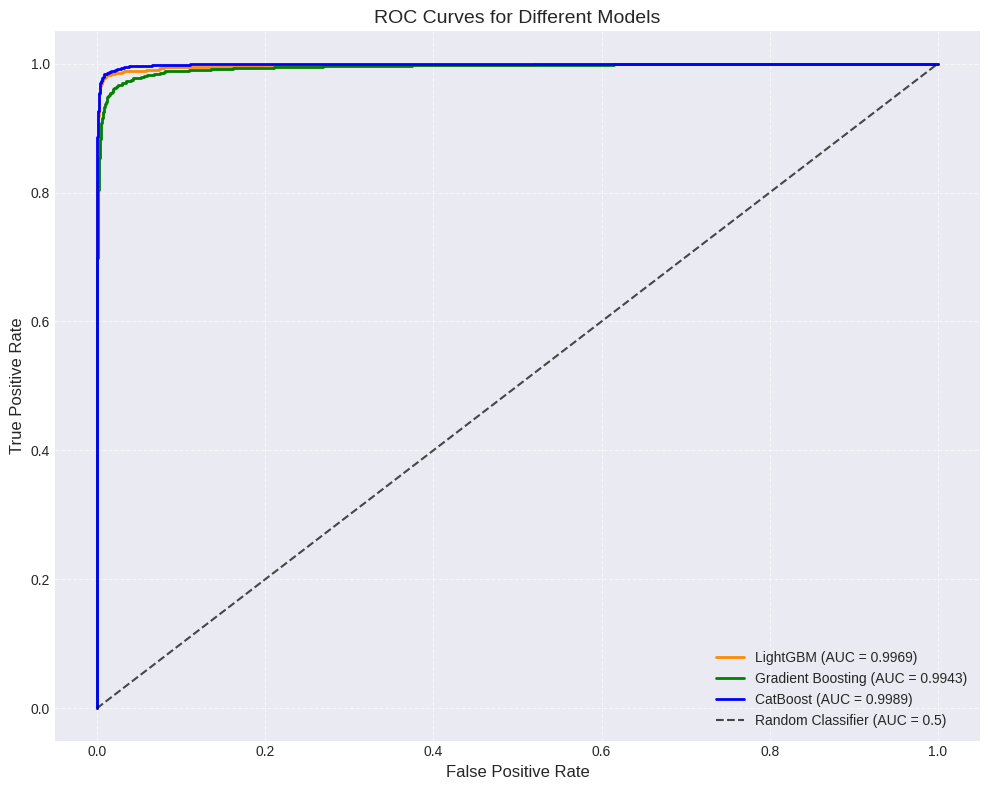

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
import warnings
warnings.filterwarnings('ignore')


# Set a style for beautiful plots
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(10, 8))

# 1. LightGBM Model
lgb_probs = lgb_model.predict_proba(X_val_scaled)[:, 1]
lgb_fpr, lgb_tpr, _ = roc_curve(y_val_int, lgb_probs)
lgb_auc = auc(lgb_fpr, lgb_tpr)
plt.plot(lgb_fpr, lgb_tpr, label=f'LightGBM (AUC = {lgb_auc:.4f})', color='darkorange', linewidth=2)

# 2. Gradient Boosting Model
gb_probs = gb_model.predict_proba(X_val_scaled)[:, 1]
gb_fpr, gb_tpr, _ = roc_curve(y_val_int, gb_probs)
gb_auc = auc(gb_fpr, gb_tpr)
plt.plot(gb_fpr, gb_tpr, label=f'Gradient Boosting (AUC = {gb_auc:.4f})', color='green', linewidth=2)

# 3. CatBoost Model
cb_probs = cb_model.predict_proba(X_val_scaled)[:, 1]
cb_fpr, cb_tpr, _ = roc_curve(y_val_int, cb_probs)
cb_auc = auc(cb_fpr, cb_tpr)
plt.plot(cb_fpr, cb_tpr, label=f'CatBoost (AUC = {cb_auc:.4f})', color='blue', linewidth=2)

# Plotting the random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', alpha=0.7)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for Different Models', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K

# 1. Восстанавливаем ИХ официальные маркеры метрик (recall, precision, f1_m)
def recall_m(y_true, y_pred):
    y_true = K.cast(y_true, 'float32') # Cast y_true to float32 for type compatibility
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    y_true = K.cast(y_true, 'float32') # Cast y_true to float32 for type compatibility
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

print("🚀 ИХ маркеры успешно воссозданы. Начинаю обучение глубокой сети...")

# 2. Собираем мощную многослойную модель
model_deep = Sequential()
model_deep.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model_deep.add(Dropout(0.3))  # Защита от переобучения
model_deep.add(Dense(64, activation='relu'))
model_deep.add(Dropout(0.2))
model_deep.add(Dense(1, activation='sigmoid'))

# 3. Компилируем строго по их канонам
model_deep.compile(loss='binary_crossentropy', optimizer='adam', metrics=[f1_m])

# Умная остановка, чтобы сеть не перегревала телефон
early_stop = EarlyStopping(monitor='val_f1_m', mode='max', patience=10, restore_best_weights=True)

# 4. Запуск на 100 эпох
history = model_deep.fit(
    X_train_scaled, y_train_int,
    epochs=100,
    batch_size=256,
    validation_data=(X_val_scaled, y_val_int),
    callbacks=[early_stop],
    verbose=1
)

# Выводим финальный результат
scores = model_deep.evaluate(X_val_scaled, y_val_int, verbose=0)
print(f"\n🏆 ФИНАЛЬНАЯ F1-МЕРА НЕЙРОСЕТИ: {scores[1]:.4f}")

🚀 ИХ маркеры успешно воссозданы. Начинаю обучение глубокой сети...
Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - f1_m: 0.3837 - loss: 0.2154 - val_f1_m: 0.7104 - val_loss: 0.1026
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - f1_m: 0.7262 - loss: 0.1111 - val_f1_m: 0.8597 - val_loss: 0.0606
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - f1_m: 0.8265 - loss: 0.0795 - val_f1_m: 0.9071 - val_loss: 0.0451
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - f1_m: 0.8689 - loss: 0.0602 - val_f1_m: 0.9319 - val_loss: 0.0359
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - f1_m: 0.8956 - loss: 0.0508 - val_f1_m: 0.9452 - val_loss: 0.0302
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - f1_m: 0.9123 - loss: 0.0418 - val_f1_m: 0.9509 - val_loss: 0.0265
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - f1_m: 0.9245 - loss: 0.0367 - val_f1_m: 0.9620 - val_loss: 0.0235
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - f1_m: 0.9350 - loss: 0.0320 - 